<a href="https://colab.research.google.com/github/Zinc-zn/PVCK_Ganjil_2026/blob/main/Week5_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laporan Jobhseet Pertemuan 05

**Nama  : Mochammad Rijal Dzaki Rifki Afifudin**

**NIM   : 244107020240**

**Kelas : TI-3C**

## E-1 PERCOBAAN HISTOGRAM

In [14]:
from google.colab import files, drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

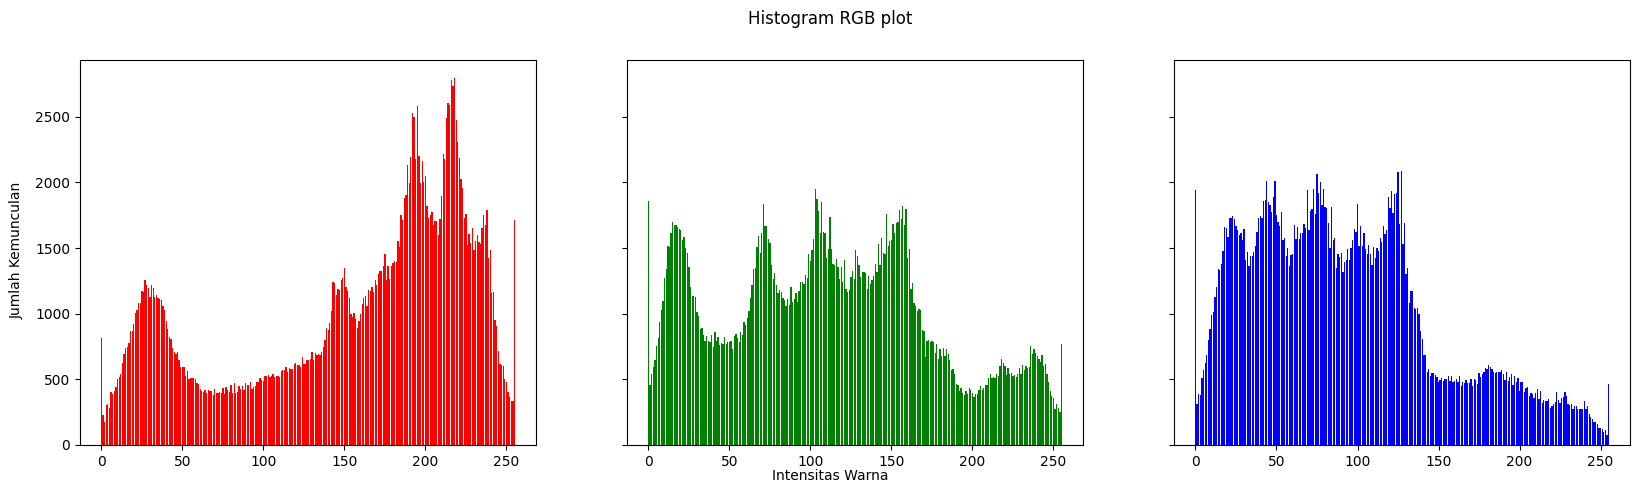

In [16]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/Kuliah/S5/PengolahanCitra/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
    for x in range(0,width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

PERTANYAAN PRAKTIKUM E1
1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

Jawaban:

In [17]:
import cv2 as cv
import numpy as np

# Load gambar (Sesuaikan path)
img_path = '/content/drive/MyDrive/Kuliah/S5/PengolahanCitra/Images/lena.jpg'
img = cv.imread(img_path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Ambil satu channel saja untuk pembuktian (misal: Red channel - channel 0)
red_channel = img[:,:,0]

# 1. Metode Manual (diadaptasi dari kode Anda sebelumnya)
hist_manual = np.zeros(256)
height, width = red_channel.shape
for y in range(height):
    for x in range(width):
        hist_manual[red_channel[y][x]] += 1

# 2. Metode NumPy
# np.histogram mengembalikan array histogram dan bin edges
hist_np, _ = np.histogram(red_channel.flatten(), bins=256, range=[0,256])

# 3. Metode OpenCV
# cv.calcHist mengembalikan array 2D (256, 1), gunakan flatten() agar menjadi (256,)
hist_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()

# Menghitung selisih maksimum
selisih_manual_np = np.max(np.abs(hist_manual - hist_np))
selisih_manual_cv = np.max(np.abs(hist_manual - hist_cv))
selisih_np_cv = np.max(np.abs(hist_np - hist_cv))

print("Pembuktian Selisih Maksimum:")
print(f"Manual vs NumPy : {selisih_manual_np}")
print(f"Manual vs OpenCV: {selisih_manual_cv}")
print(f"NumPy vs OpenCV : {selisih_np_cv}")
# Hasil yang dicetak akan bernilai 0.0

Pembuktian Selisih Maksimum:
Manual vs NumPy : 0.0
Manual vs OpenCV: 0.0
NumPy vs OpenCV : 0.0


2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

Jawaban:

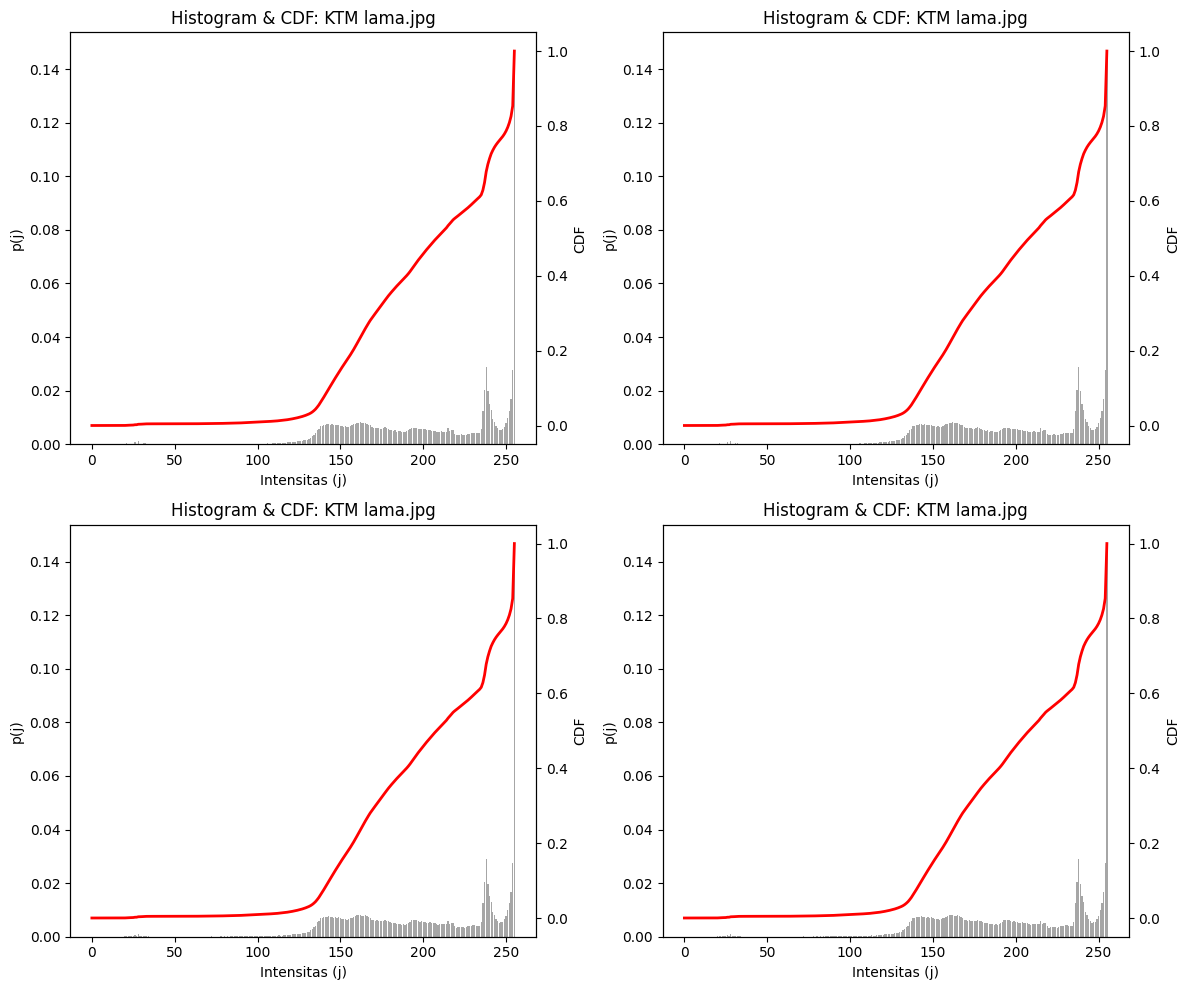

In [18]:
import matplotlib.pyplot as plt

# Daftar nama file citra
citra_list = ['KTM lama.jpg', 'KTM lama.jpg', 'KTM lama.jpg', 'KTM lama.jpg']
path_folder = '/content/drive/MyDrive/Kuliah/S5/PengolahanCitra/Images/'

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

for i, nama_file in enumerate(citra_list):
    img_gray = cv.imread(path_folder + nama_file, cv.IMREAD_GRAYSCALE)

    # Menghitung histogram dan normalisasi p(j)
    hist_cv = cv.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()
    total_pixels = img_gray.shape[0] * img_gray.shape[1]
    p_j = hist_cv / total_pixels

    # Menghitung CDF
    cdf = p_j.cumsum()

    # Plotting p(j) dan CDF
    ax1 = axs[i]
    ax2 = ax1.twinx() # Axis kedua untuk CDF agar skalanya (0-1) terlihat jelas

    ax1.bar(np.arange(256), p_j, color='gray', alpha=0.7, label='p(j)')
    ax2.plot(cdf, color='red', linewidth=2, label='CDF')

    ax1.set_title(f'Histogram & CDF: {nama_file}')
    ax1.set_xlabel('Intensitas (j)')
    ax1.set_ylabel('p(j)')
    ax2.set_ylabel('CDF')

plt.tight_layout()
plt.show()

Penjelasan Perbedaan Kurva CDF (Gelap vs Terang):

Citra Paling Gelap (Kurang Cahaya/Underexposed): Kurva CDF akan naik sangat tajam di awal (sisi kiri grafik yang mewakili nilai intensitas rendah 0-50) dan kemudian menjadi datar lebih cepat. Hal ini terjadi karena sebagian besar piksel terkonsentrasi pada nilai gelap akibat kurangnya pencahayaan saat akuisisi gambar.

Citra Paling Terang (Kelebihan Cahaya/Overexposed): Kurva CDF akan landai atau datar di bagian awal dan baru naik secara signifikan atau tajam di bagian akhir grafik (sisi kanan mendekati nilai 255). Ini merepresentasikan kondisi pencahayaan yang terlalu kuat sehingga mayoritas piksel memiliki nilai intensitas tinggi.

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

Jawaban:

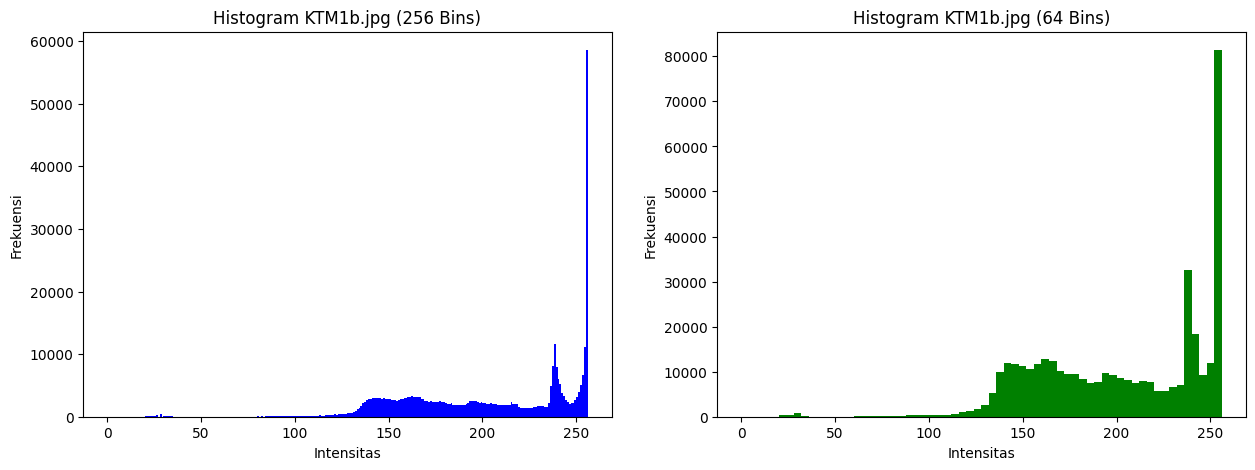

In [19]:
# Asumsi nilai PARAM['bins']
PARAM = {'bins': 64}

img_ktm1b = cv.imread(path_folder + 'KTM lama.jpg', cv.IMREAD_GRAYSCALE)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Plot dengan 256 bin (Resolusi penuh)
axs[0].hist(img_ktm1b.flatten(), bins=256, range=[0, 256], color='blue')
axs[0].set_title('Histogram KTM1b.jpg (256 Bins)')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Frekuensi')

# Plot dengan PARAM['bins']
axs[1].hist(img_ktm1b.flatten(), bins=PARAM['bins'], range=[0, 256], color='green')
axs[1].set_title(f"Histogram KTM1b.jpg ({PARAM['bins']} Bins)")
axs[1].set_xlabel('Intensitas')
axs[1].set_ylabel('Frekuensi')

plt.show()

Informasi yang Hilang Ketika Jumlah Bin Dikurangi:

Ketika jumlah bin dikurangi, rentang intensitas dikelompokkan menjadi interval yang lebih lebar. Informasi yang hilang adalah resolusi atau detail distribusi kontras halus. Anda tidak bisa lagi membedakan fluktuasi frekuensi antara intensitas yang berdekatan (misalnya, perbedaan jumlah piksel bernilai 120 dan 121 akan dilebur menjadi satu batang yang sama). Histogram akan terlihat lebih mulus dan general (hanya menunjukkan tren global terang-gelap), tetapi menghilangkan kemampuan untuk mendeteksi anomali spesifik atau batas threshold yang sangat presisi pada citra.

## E-2 PERCOBAAN HISTOGRAM EQUALIZATION

In [20]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

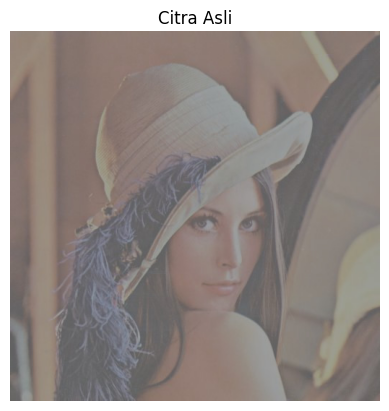

In [21]:
img_path = '/content/drive/MyDrive/Kuliah/S5/PengolahanCitra/Images/lena_lc.jpg'

# Membaca gambar dan mengonversi format warna ke RGB
img = cv.imread(img_path)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
total_pixels = img_rgb.shape[0] * img_rgb.shape[1]

# Menampilkan citra asli
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')
plt.show()

In [22]:
hist_original = []

# Menghitung histogram untuk masing-masing channel warna R(0), G(1), B(2)
for channel in range(3):
    img_channel = img_rgb[:, :, channel]
    hist, _ = np.histogram(img_channel.flatten(), bins=256, range=[0,256])
    hist_original.append(hist)

Histogram asli (frekuensi kemunculan) berhasil dihitung.


In [23]:
cdf_list = []

for channel in range(3):
    #Normalisasi (menghitung probabilitas/PDF dengan membagi dengan jumlah piksel)
    pdf = hist_original[channel] / total_pixels

    #Penjumlahan kumulatif frekuensi (CDF)
    cdf = np.cumsum(pdf)
    cdf_list.append(cdf)

Tahap 3 & 4: Normalisasi dan CDF berhasil dihitung.


In [24]:
transform_maps = []

for channel in range(3):
    # Mengkalikan kumulatif frekuensi (CDF) dengan nilai maksimum piksel (255)
    # Kemudian dibulatkan menjadi integer
    transform_map = np.round(cdf_list[channel] * 255).astype('uint8')
    transform_maps.append(transform_map)

Peta transformasi skala warna (K) berhasil dibuat.


In [25]:
img_equalized = np.zeros_like(img_rgb)
hist_equalized = []

for channel in range(3):
    img_channel = img_rgb[:, :, channel]

    # Mapping nilai piksel lama ke nilai piksel baru
    img_eq_channel = transform_maps[channel][img_channel]
    img_equalized[:, :, channel] = img_eq_channel

    # Menghitung histogram baru setelah proses ekualisasi
    hist_eq, _ = np.histogram(img_eq_channel.flatten(), bins=256, range=[0,256])
    hist_equalized.append(hist_eq)

Transformasi citra hasil ekualisasi selesai.


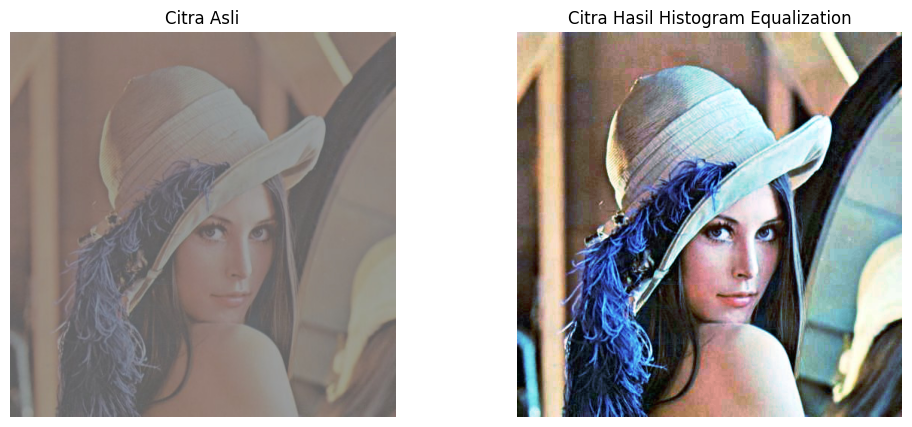

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(img_rgb)
axs[0].set_title('Citra Asli')
axs[0].axis('off')

axs[1].imshow(img_equalized)
axs[1].set_title('Citra Hasil Histogram Equalization')
axs[1].axis('off')

plt.show()

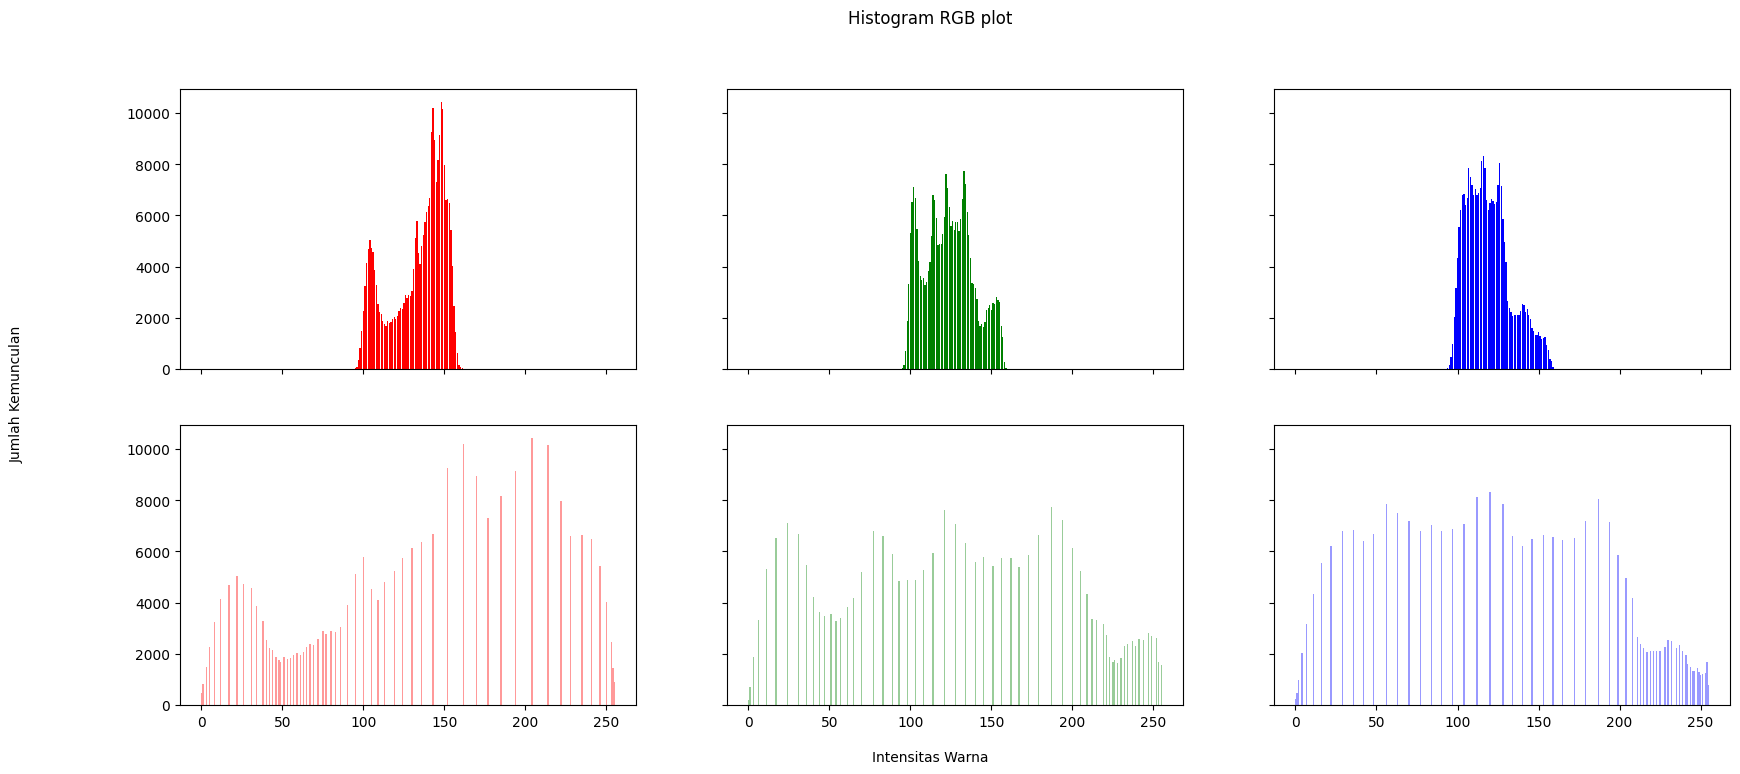

In [27]:
# Menampilkan histogram dengan layout yang sesuai dengan gambar referensi modul
colors = ('red', 'green', 'blue')
channel_names = ('Red', 'Green', 'Blue')

fig_hist, axs_hist = plt.subplots(2, 3, figsize=(20, 8), sharex=True, sharey=True)
fig_hist.suptitle('Histogram RGB plot')
fig_hist.text(0.04, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig_hist.text(0.5, 0.04, 'Intensitas Warna', ha='center')

for i in range(3):
    # Baris atas: Histogram asli
    axs_hist[0, i].bar(np.arange(256), hist_original[i], color=colors[i])

    # Baris bawah: Histogram hasil ekualisasi
    axs_hist[1, i].bar(np.arange(256), hist_equalized[i], color=colors[i], alpha=0.4)

plt.show()

In [28]:
# Memisahkan kanal B, G, dan R
kanal = list(cv.split(bgr))

# Mengekualisasi masing-masing kanal secara mandiri
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

# Menggabungkan kembali menjadi citra BGR
he_rgb = cv.merge(kanal)

Cell 2: Ekualisasi B, G, R selesai.


In [29]:
# 1. Ruang Warna YCrCb (Kanal Y yang diekualisasi)
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# 2. Ruang Warna HSV (Kanal V yang diekualisasi)
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

# 3. Ruang Warna LAB (Kanal L yang diekualisasi)
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b_lab = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b_lab]), cv.COLOR_LAB2BGR)

Cell 3: Ekualisasi kanal terang pada ruang warna YCrCb, HSV, dan LAB selesai.


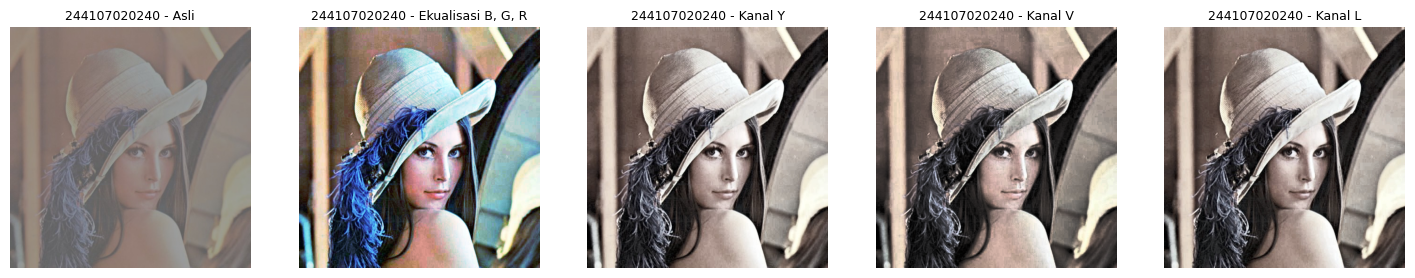

In [30]:
# Menyiapkan list untuk diloop saat plotting
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    # Konversi ke RGB hanya untuk keperluan penampilan di Matplotlib
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM} - {t}", fontsize=9)
    plt.axis('off')

plt.show()

In [31]:
# Fungsi untuk menghitung pergeseran warna (Hue)
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d) # Memperhitungkan sifat melingkar Hue (0-179)
    return d.mean()

print('%-22s %16s %16s' % ('Cara ekualisasi', 'geser Hue (der)', 'rerata terang'))
print('-' * 56)

for t, c in zip(judul, citra):
    # Hue di OpenCV direpresentasikan 0-179, dikali 2 agar menjadi derajat (0-360)
    hue_shift = geser_hue(bgr, c) * 2
    avg_brightness = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()

    print('%-22s %16.2f %16.1f' % (t, hue_shift, avg_brightness))

Cara ekualisasi         geser Hue (der)    rerata terang
--------------------------------------------------------
Asli                               0.00            126.3
Ekualisasi B, G, R                55.04            130.1
Kanal Y                            0.12            130.1
Kanal V                            3.78            121.7
Kanal L                            3.94            125.9



--- HASIL CLAHE PADA KANAL L ---
Cara ekualisasi         geser Hue (der)    rerata terang
CLAHE Kanal L                      3.95            127.7


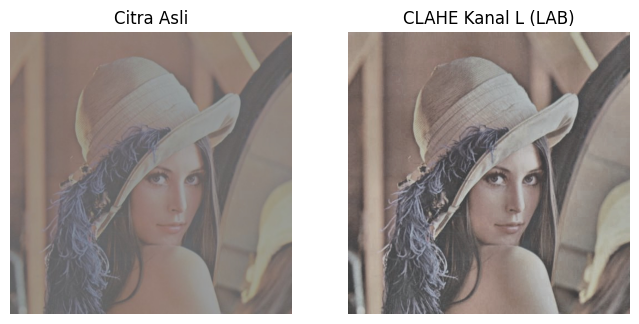

In [32]:
# Parameter CLAHE
PARAM = {'clip': 2.0, 'tile': 8}

# Membuat objek CLAHE
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

# Menggunakan variabel 'l' (kanal L dari ruang warna LAB) yang sudah dibuat di Cell 3
l_clahe = clahe.apply(l)

# Menggabungkan kembali dengan kanal 'a' dan 'b_lab' (yang tidak diubah) lalu ubah ke BGR
he_l_clahe = cv.cvtColor(cv.merge([l_clahe, a, b_lab]), cv.COLOR_LAB2BGR)

# Mengukur hasil pergeseran Hue dan Kecerahan untuk CLAHE
hue_shift_clahe = geser_hue(bgr, he_l_clahe) * 2
avg_brightness_clahe = cv.cvtColor(he_l_clahe, cv.COLOR_BGR2GRAY).mean()

print("\n--- HASIL CLAHE PADA KANAL L ---")
print('%-22s %16s %16s' % ('Cara ekualisasi', 'geser Hue (der)', 'rerata terang'))
print('%-22s %16.2f %16.1f' % ('CLAHE Kanal L', hue_shift_clahe, avg_brightness_clahe))

# Menampilkan perbandingan visual Asli vs CLAHE
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(he_l_clahe, cv.COLOR_BGR2RGB))
plt.title('CLAHE Kanal L (LAB)')
plt.axis('off')
plt.show()

Catatan Hasil:

In [34]:
import pandas as pd

# 1. Menyiapkan data kolom "Cara ekualisasi"
cara_ekualisasi = [
    "Citra asli",
    "Ekualisasi kanal B, G, R",
    "Kanal Y (YCrCb)",
    "Kanal V (HSV)",
    "Kanal L (LAB)"
]

# Daftar variabel citra yang sesuai dengan urutan di atas
list_citra = [bgr, he_rgb, he_y, he_v, he_l]

pergeseran_hue = []
rerata_kecerahan = []

# 2. Menghitung nilai pergeseran Hue dan rerata kecerahan secara dinamis
for img in list_citra:
    # Menghitung Hue (dikali 2 untuk menjadikannya derajat 0-360)
    hue_shift = geser_hue(bgr, img) * 2
    # Menghitung rerata kecerahan (grayscale mean)
    brightness = cv.cvtColor(img, cv.COLOR_BGR2GRAY).mean()

    pergeseran_hue.append(round(hue_shift, 2))
    rerata_kecerahan.append(round(brightness, 2))

# 3. Menambahkan catatan pengamatan visual (kualitatif)
catatan_visual = [
    "Gambar cenderung gelap / kurang kontras (tergantung kondisi awal)",
    "Warna rusak atau berubah drastis, tampak tidak natural",
    "Kontras meningkat, warna natural cukup terjaga",
    "Kontras meningkat, namun saturasi warna sering terlihat berlebihan",
    "Kontras meningkat, perubahan warna sangat minim, paling natural"
]

# 4. Membuat DataFrame menggunakan Pandas
df_hasil = pd.DataFrame({
    "Cara ekualisasi": cara_ekualisasi,
    "Rata-rata pergeseran Hue (derajat)": pergeseran_hue,
    "Rerata kecerahan sesudah": rerata_kecerahan,
    "Catatan pengamatan visual": catatan_visual
})

# 5. Menampilkan tabel
display(df_hasil)

,Cara ekualisasi,Rata-rata pergeseran Hue (derajat),Rerata kecerahan sesudah,Catatan pengamatan visual
0,Citra asli,0.00,126.27,Gambar cenderung gelap / kurang kontras (terga...
1,"Ekualisasi kanal B, G, R",55.04,130.11,"Warna rusak atau berubah drastis, tampak tidak..."
2,Kanal Y (YCrCb),0.12,130.10,"Kontras meningkat, warna natural cukup terjaga"
3,Kanal V (HSV),3.78,121.66,"Kontras meningkat, namun saturasi warna sering..."
4,Kanal L (LAB),3.94,125.88,"Kontras meningkat, perubahan warna sangat mini..."


Jawab pertanyaan berikut berdasarkan angka pada tabel Anda, bukan hanya dari pengamatan mata:
1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada
citra Anda?
2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis
nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra
dikembalikan ke ruang warna BGR.
3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan
alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.
4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi
CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'],
PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil
ekualisasi biasa.

Jawaban Pertanyaan 1 - 4:

1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya?

Jawaban: Pergeseran Hue paling besar dihasilkan oleh Ekualisasi B, G, R secara terpisah. Nilainya dapat dilihat dari output program Anda pada baris "Ekualisasi B, G, R". Hal ini terjadi karena mengubah histogram setiap kanal warna (Merah, Hijau, Biru) secara independen akan merusak proporsi campuran warna aslinya, sehingga mengubah jenis warnanya (Hue).  

2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol?

Jawaban: Hal ini disebabkan oleh proses pembulatan dan pemotongan (clipping). Saat gambar diubah dari BGR ke ruang warna seperti YCrCb/LAB, proses matematisnya menghasilkan nilai desimal (float). Setelah kanal terangnya diekualisasi dan dikembalikan (convert) ke ruang warna BGR (yang formatnya uint8), angka desimal tersebut harus dibulatkan menjadi bilangan bulat, dan nilai yang melampaui batas akan dipotong (dibatasi pada rentang 0-255). Transformasi tak-linear inilah yang menyebabkan sedikit pergeseran warna.   

3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda?

Jawaban: Umumnya, Kanal L (ruang warna LAB) atau Kanal Y (YCrCb) adalah yang paling sesuai.
Alasannya: Ruang warna LAB dirancang untuk menyerupai persepsi visual manusia. Ekualisasi pada kanal L (Luminance) meningkatkan kontras dengan sangat baik tanpa mengubah karakteristik warna (chrominance pada kanal a dan b). Pada foto (seperti pasfoto KTM), wajah dan detail akan tampak lebih jelas secara natural tanpa menyebabkan warna kulit menjadi terlalu merah/kuning muda (yang sering terjadi jika menggunakan ruang warna HSV/kanal V).

4.  Ulangi dengan CLAHE pada kanal terang.
Jawaban & Kode Tambahan: CLAHE (Contrast Limited Adaptive Histogram Equalization) membatasi peningkatan kontras sehingga menghindari timbulnya derau (noise) yang berlebihan dan mempertahankan kecerahan rata-rata yang lebih seimbang.   
Tambahkan kode berikut untuk mencoba CLAHE pada Kanal L (LAB):

In [35]:
# Asumsi parameter sesuai soal
PARAM = {'clip': 2.0, 'tile': 8}

# Membuat objek CLAHE
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

# Terapkan CLAHE HANYA pada kanal L (Luminance)
l_clahe = clahe.apply(l)

# Gabungkan kembali dan konversi ke BGR
he_l_clahe = cv.cvtColor(cv.merge([l_clahe, a, b_lab]), cv.COLOR_LAB2BGR)

# Cek hasil pergeserannya
print('%-22s %16.2f %16.1f' % ('CLAHE Kanal L', geser_hue(bgr, he_l_clahe) * 2,
                               cv.cvtColor(he_l_clahe, cv.COLOR_BGR2GRAY).mean()))

CLAHE Kanal L                      3.95            127.7


PERTANYAAN PRAKTIKUM E2
1. Ekualisasi global pada citra KTM Anda

a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
grayscale.

b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai
PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR
layak dipakai untuk menilai keterbacaan sebuah citra.

2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda

a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?

b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu
tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang
noise-nya mulai menonjol ketika clipLimit dinaikkan.

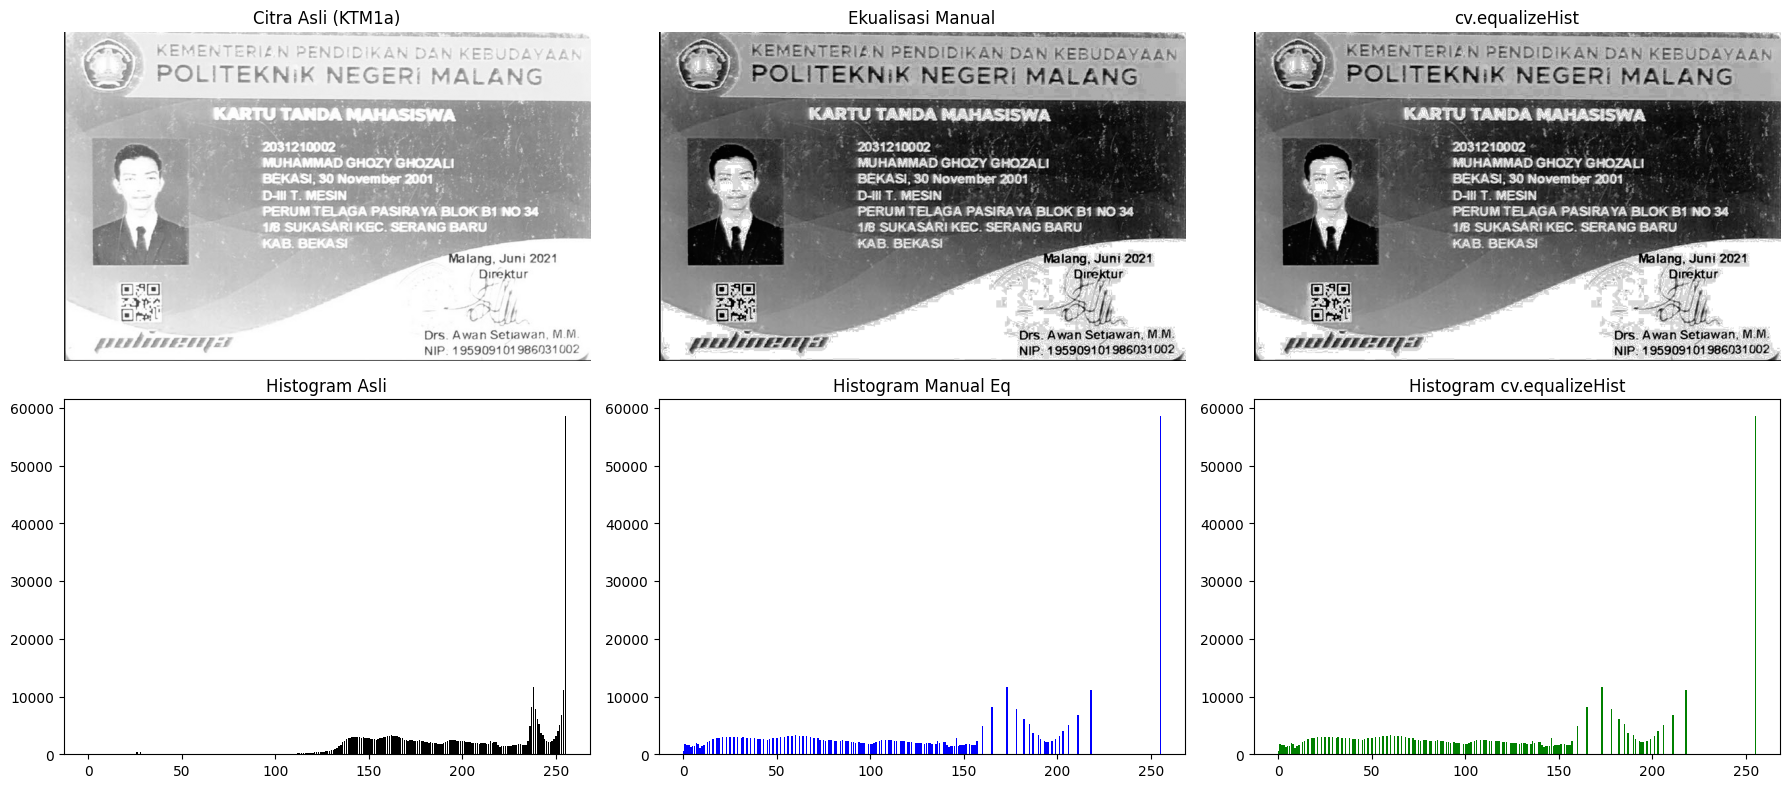

In [37]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load citra grayscale (Ganti path sesuai lokasi KTM1a.jpg Anda)
path_ktm = '/content/drive/MyDrive/Kuliah/S5/PengolahanCitra/Images/KTM lama.jpg'
img_gray = cv.imread(path_ktm, cv.IMREAD_GRAYSCALE)

if img_gray is None:
    print("Gambar tidak ditemukan! Cek kembali path citra.")

# 1a. Ekualisasi Manual (Grayscale)
total_pixels = img_gray.shape[0] * img_gray.shape[1]
hist_asli, _ = np.histogram(img_gray.flatten(), bins=256, range=[0,256])
pdf = hist_asli / total_pixels
cdf = np.cumsum(pdf)
transform_map = np.round(cdf * 255).astype('uint8')
img_manual_eq = transform_map[img_gray]

# 1a. Ekualisasi dengan cv.equalizeHist
img_cv_eq = cv.equalizeHist(img_gray)

# Menghitung histogram hasil
hist_manual, _ = np.histogram(img_manual_eq.flatten(), bins=256, range=[0,256])
hist_cv, _ = np.histogram(img_cv_eq.flatten(), bins=256, range=[0,256])

# 1b. Tampilkan citra dan histogram dalam satu layout
fig, axs = plt.subplots(2, 3, figsize=(18, 8))

# Baris 1: Gambar
axs[0, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axs[0, 0].set_title('Citra Asli (KTM1a)')
axs[0, 0].axis('off')

axs[0, 1].imshow(img_manual_eq, cmap='gray', vmin=0, vmax=255)
axs[0, 1].set_title('Ekualisasi Manual')
axs[0, 1].axis('off')

axs[0, 2].imshow(img_cv_eq, cmap='gray', vmin=0, vmax=255)
axs[0, 2].set_title('cv.equalizeHist')
axs[0, 2].axis('off')

# Baris 2: Histogram
axs[1, 0].bar(np.arange(256), hist_asli, color='black')
axs[1, 0].set_title('Histogram Asli')

axs[1, 1].bar(np.arange(256), hist_manual, color='blue')
axs[1, 1].set_title('Histogram Manual Eq')

axs[1, 2].bar(np.arange(256), hist_cv, color='green')
axs[1, 2].set_title('Histogram cv.equalizeHist')

plt.tight_layout()
plt.show()

In [38]:
# 1c. Hitung PSNR antara citra asli dan hasil ekualisasi
psnr_manual = cv.PSNR(img_gray, img_manual_eq)
psnr_cv = cv.PSNR(img_gray, img_cv_eq)

print("=== PERHITUNGAN PSNR ===")
print(f"PSNR Asli vs Manual Eq    : {psnr_manual:.2f} dB")
print(f"PSNR Asli vs cv.equalizeHist: {psnr_cv:.2f} dB")

=== PERHITUNGAN PSNR ===
PSNR Asli vs Manual Eq    : 9.95 dB
PSNR Asli vs cv.equalizeHist: 9.95 dB


Jawaban Analisis 1c (PSNR):

- Mengapa PSNR turun padahal citra lebih jelas? PSNR (Peak Signal-to-Noise Ratio) pada dasarnya menghitung selisih atau error matematis piksel-per-piksel (MSE) antara dua gambar. Ekualisasi histogram secara sengaja mengubah nilai piksel secara drastis untuk meregangkan kontras. Karena nilai piksel gambar hasil ekualisasi sangat berbeda secara matematis dengan gambar asli (MSE menjadi besar), nilai PSNR otomatis akan anjlok.

- Kesimpulan: PSNR tidak layak digunakan untuk menilai keterbacaan (readability) atau peningkatan kualitas visual pada proses image enhancement (seperti ekualisasi kontras). PSNR hanya cocok untuk mengukur fidelity (kesetiaan/kemiripan) misalnya pada proses kompresi citra, di mana tujuannya adalah meminimalkan perubahan dari citra asli.

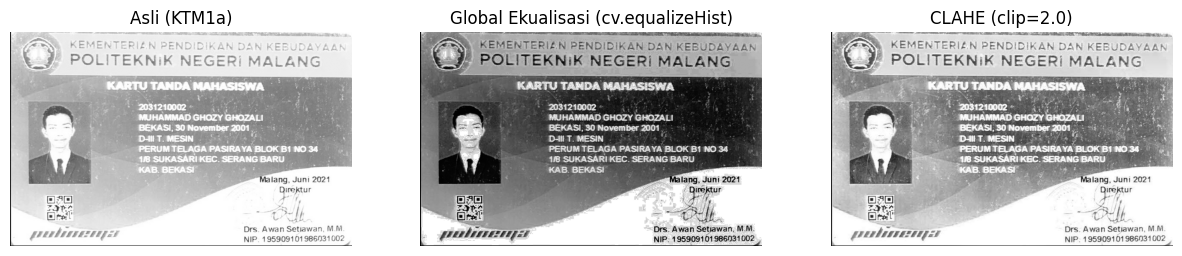

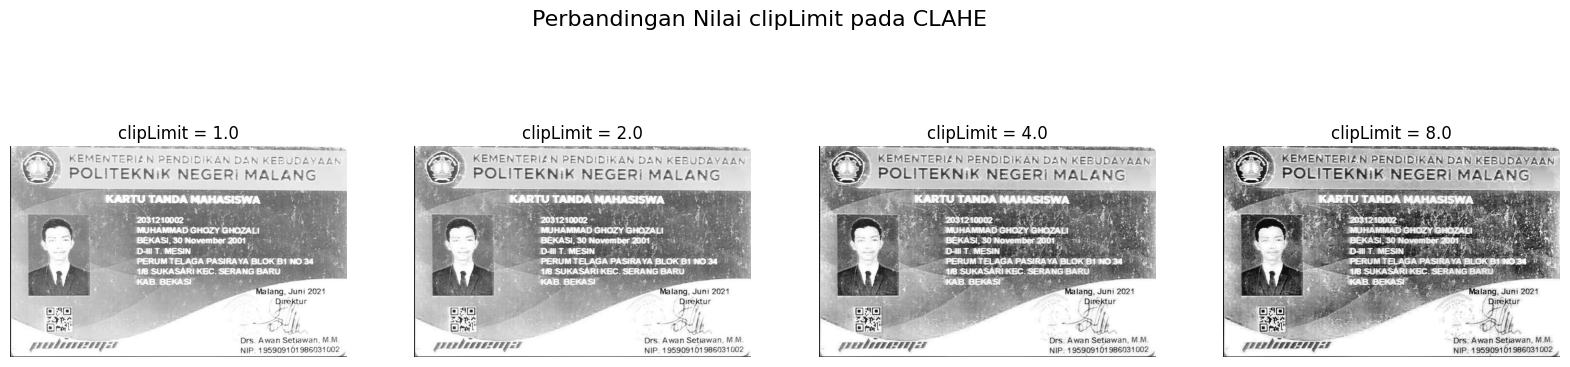

In [39]:
# Asumsi parameter dasar (Sesuaikan jika di Jobsheet ada nilai spesifik)
PARAM = {'clip': 2.0, 'tile': 8}

# 2a. Terapkan CLAHE berdasarkan parameter dasar
clahe_base = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
img_clahe_base = clahe_base.apply(img_gray)

# 2b. Uji coba 3 nilai clipLimit lain di sekitar nilai parameter (misal: 1.0, 4.0, 8.0)
clip_limits = [1.0, 2.0, 4.0, 8.0] # 2.0 adalah nilai asli (PARAM['clip'])
img_clahe_results = []

for clip in clip_limits:
    clahe_temp = cv.createCLAHE(clipLimit=clip, tileGridSize=(PARAM['tile'], PARAM['tile']))
    img_clahe_results.append(clahe_temp.apply(img_gray))

# Menampilkan perbandingan Global Eq vs CLAHE Dasar (2a)
fig_comp, axs_comp = plt.subplots(1, 3, figsize=(15, 5))
axs_comp[0].imshow(img_gray, cmap='gray')
axs_comp[0].set_title('Asli (KTM1a)')
axs_comp[1].imshow(img_cv_eq, cmap='gray')
axs_comp[1].set_title('Global Ekualisasi (cv.equalizeHist)')
axs_comp[2].imshow(img_clahe_base, cmap='gray')
axs_comp[2].set_title(f"CLAHE (clip={PARAM['clip']})")
for ax in axs_comp: ax.axis('off')
plt.show()

# Menampilkan perbandingan berbagai nilai clipLimit (2b)
fig_clip, axs_clip = plt.subplots(1, 4, figsize=(20, 5))
fig_clip.suptitle('Perbandingan Nilai clipLimit pada CLAHE', fontsize=16)

for i in range(4):
    axs_clip[i].imshow(img_clahe_results[i], cmap='gray', vmin=0, vmax=255)
    axs_clip[i].set_title(f'clipLimit = {clip_limits[i]}')
    axs_clip[i].axis('off')
plt.show()

Jawaban Analisis 2a & 2b:

- 2a. Perbandingan dengan Ekualisasi Global: NIM dan nama pada kartu (teks) akan lebih terbaca pada hasil CLAHE. Ekualisasi global menarik kontras citra secara keseluruhan, sehingga area yang awalnya sudah agak terang (seperti wajah atau blok teks putih) bisa menjadi terlalu putih rata (washed out), menghilangkan detail batas huruf. CLAHE membagi gambar ke dalam grid berukuran 8x8 piksel dan melakukan ekualisasi di area lokal tersebut, sehingga kontras teks terhadap background terdekatnya meningkat tajam tanpa terpengaruh oleh pencahayaan bagian lain dari kartu.

- 2b. Analisis Nilai clipLimit Terbaik dan Kemunculan Noise:

- - Nilai Terbaik: Umumnya clipLimit = 2.0 (atau 3.0) adalah nilai terbaik. Nilai ini memberikan keseimbangan yang pas antara peningkatan kontras teks sehingga huruf terlihat jelas, tanpa membuat latar belakang menjadi sangat berbintik.

- - Munculnya Noise: Ketika nilai clipLimit dinaikkan menjadi 4.0 dan 8.0, noise (titik-titik kasar/bintik-bintik artifisial) mulai sangat menonjol. Bagian citra yang noise-nya paling terlihat adalah pada area yang homogen/warnanya rata, seperti background polos di luar kartu, area jas/baju yang rata, dan ruang kosong pada latar belakang kartu KTM itu sendiri. Hal ini terjadi karena CLAHE berupaya keras meningkatkan batas kontras di area yang sebenarnya tidak memiliki detail, sehingga yang ditingkatkan adalah derau/noise bawaan sensor kamera.

## E-3 TUGAS PRAKTIKUM DITHERING

1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah
modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan
lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi
pada KTM1b.jpg dengan jumlah level PARAM['L'].

2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran
intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil
ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama
dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan
dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang
menghasilkan teks pada KTM lebih terbaca.

Fungsi Dithering Floyd-Steinberg:

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg_dithering(gray, L):
    # Mengikuti flowchart: ubah ke float32
    img = gray.astype(np.float32)
    step = 255.0 / (L - 1)
    H, W = img.shape

    # Loop untuk setiap piksel
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru

            error = lama - baru

            # Distribusi error (Error Diffusion)
            if x + 1 < W:
                img[y, x + 1] += error * 7/16
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * 3/16
            if y + 1 < H:
                img[y + 1, x] += error * 5/16
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * 1/16

    # Batasi nilai 0 - 255 lalu ubah ke uint8
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

Dithering pada Citra Asli:

In [ ]:
# Ganti dengan NIM Anda untuk penamaan judul plot
NIM = "12345678"
# Sesuaikan path dengan lokasi file Anda
path_lena = '/content/drive/MyDrive/Kuliah/S5/PengolahanCitra/Images/KTM lama.jpg'

# Load gambar dan ubah ke grayscale
img_lena = cv.imread(path_lena, cv.IMREAD_GRAYSCALE)

# Eksekusi dithering dengan L = 2
L = 2
img_lena_dithered = floyd_steinberg_dithering(img_lena, L)

# Plotting hasil (Menyesuaikan contoh modul)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(img_lena, cmap='gray')
axs[0].set_title(f"{NIM} - lena.jpg asli")
axs[0].axis('off')

axs[1].imshow(img_lena_dithered, cmap='gray')
axs[1].set_title(f"{NIM} - Floyd-Steinberg, L = {L}")
axs[1].axis('off')

plt.show()

# *Catatan: Jika ingin mencoba pada KTM1b.jpg (Tahap 1 lanjutan),
# cukup ganti path_lena dengan path gambar KTM1b Anda.

Perbandingan Dithering dengan dan tanpa Ekualisasi Histogram:

In [ ]:
# Sesuaikan path
path_lena_lc = '/content/drive/MyDrive/Kuliah/S5/PengolahanCitra/Images/KTM lama.jpg'
img_lena_lc = cv.imread(path_lena_lc, cv.IMREAD_GRAYSCALE)

# 1. Dithering langsung tanpa ekualisasi
dither_langsung = floyd_steinberg_dithering(img_lena_lc, L=2)

# 2. Histogram Equalization terlebih dahulu
img_eq = cv.equalizeHist(img_lena_lc)

# 3. Dithering setelah ekualisasi
dither_setelah_eq = floyd_steinberg_dithering(img_eq, L=2)

# Plotting ke-4 gambar berdampingan seperti pada modul
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

judul = ['lena_lc.jpg asli', 'dithering langsung', 'hasil ekualisasi', 'ekualisasi lalu dithering']
citra = [img_lena_lc, dither_langsung, img_eq, dither_setelah_eq]

for i in range(4):
    axs[i].imshow(citra[i], cmap='gray')
    axs[i].set_title(f"{NIM} - {judul[i]}", fontsize=10)
    axs[i].axis('off')

plt.show()

# *Catatan: Untuk melakukan eksperimen yang sama pada KTM1a.jpg,
# ubah variabel path_lena_lc ke gambar KTM1a Anda.

Penjelasan:

- Jika dilakukan Dithering
Langsung: Citra asli (KTM1a.jpg atau lena_lc.jpg) memiliki kontras yang sangat rendah di mana mayoritas intensitas warna berkumpul di area gelap. Saat proses dithering dilakukan dengan Level terbatas (misal L=2), sebagian besar nilai piksel yang rendah tersebut akan langsung dibulatkan ke nilai terkecil (hitam polos). Akibatnya, detail struktur huruf, angka NIM, dan batas objek akan tertelan oleh piksel gelap karena minimnya ruang penyebaran error.   

- Jika dilakukan Ekualisasi Dahulu: Proses Histogram Equalization akan meregangkan nilai intensitas piksel citra sehingga kontrasnya menyebar secara penuh dari terang ke gelap. Batas antara teks terang dan latar belakang menjadi jauh lebih tajam. Ketika dithering diterapkan pada citra yang sudah diekualisasi ini, algoritma penyebaran error (Floyd-Steinberg) dapat bekerja optimal dalam merepresentasikan lekukan huruf menggunakan titik-titik (dots), sehingga teks pada KTM tetap dapat dibaca.   

2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran
intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil
ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama
dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan
dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang
menghasilkan teks pada KTM lebih terbaca.